In [1]:
""" Created on April 24, 2026 // @author: Sarah Shi """

import numpy as np
import sys 
sys.path.append('../../src/')
import mineralML as mm

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# Interactive Tools for Mapped EDS Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SarahShi/mineralML/blob/main/docs/examples/mineralML_interactive.ipynb)

This notebook demonstrates **interactive tools for exploring mineralML phase maps**. These tools require a live Python kernel and an interactive Matplotlib backend — they cannot be run on ReadTheDocs. Use the Colab badge above or run locally with `%matplotlib widget` (requires `ipympl`).

```bash
pip install ipympl
```

The tools shown here are:

- **`mm.interactive_pixels`** — click pixels to sample oxide compositions
- **`mm.interactive_line_profile`** — click to draw transects and extract line profiles
- **`mm.plot_locations`** — plot the locations of picked pixels or transects on a map

## 1. Load and run a map

First, run `mm.run_map` as usual to get the result dictionary. See the [EDS mapping notebook](mineralML_mapping.ipynb) for full details on loading and preparing data.

[ok] Mg Wt%Montaged Map Data.csv  →  Mg  (329, 283)
[ok] Ca Wt%Montaged Map Data.csv  →  Ca  (329, 283)
[ok] Al Wt%Montaged Map Data.csv  →  Al  (329, 283)
[ok] Fe Wt%Montaged Map Data.csv  →  Fe  (329, 283)
[ok] Na Wt%Montaged Map Data.csv  →  Na  (329, 283)
[ok] Mn Wt%Montaged Map Data.csv  →  Mn  (329, 283)
[ok] Cr Wt%Montaged Map Data.csv  →  Cr  (329, 283)
[ok] Ti Wt%Montaged Map Data.csv  →  Ti  (329, 283)
[ok] Si Wt%Montaged Map Data.csv  →  Si  (329, 283)
[ok] K Wt%Montaged Map Data.csv  →  K  (329, 283)
mineralML: 93107 rows — 57732 classified by neural network, 0 by empirical rules (Zircon: 0, SiO2 polymorph: 0, Carbonate: 0), 35375 skipped (invalid/empty)
prep_df: 57732 row(s) processed (of 57732 input, 0 dropped).


/Users/sarahshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:280: UserWarning: The column 'Mineral' was missing and has been filled with NaN.
  df = prep_df(df)
/Users/sarahshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:280: UserWarning: Non-numeric values in 57732 row(s) were coerced to NaN.
  df = prep_df(df)


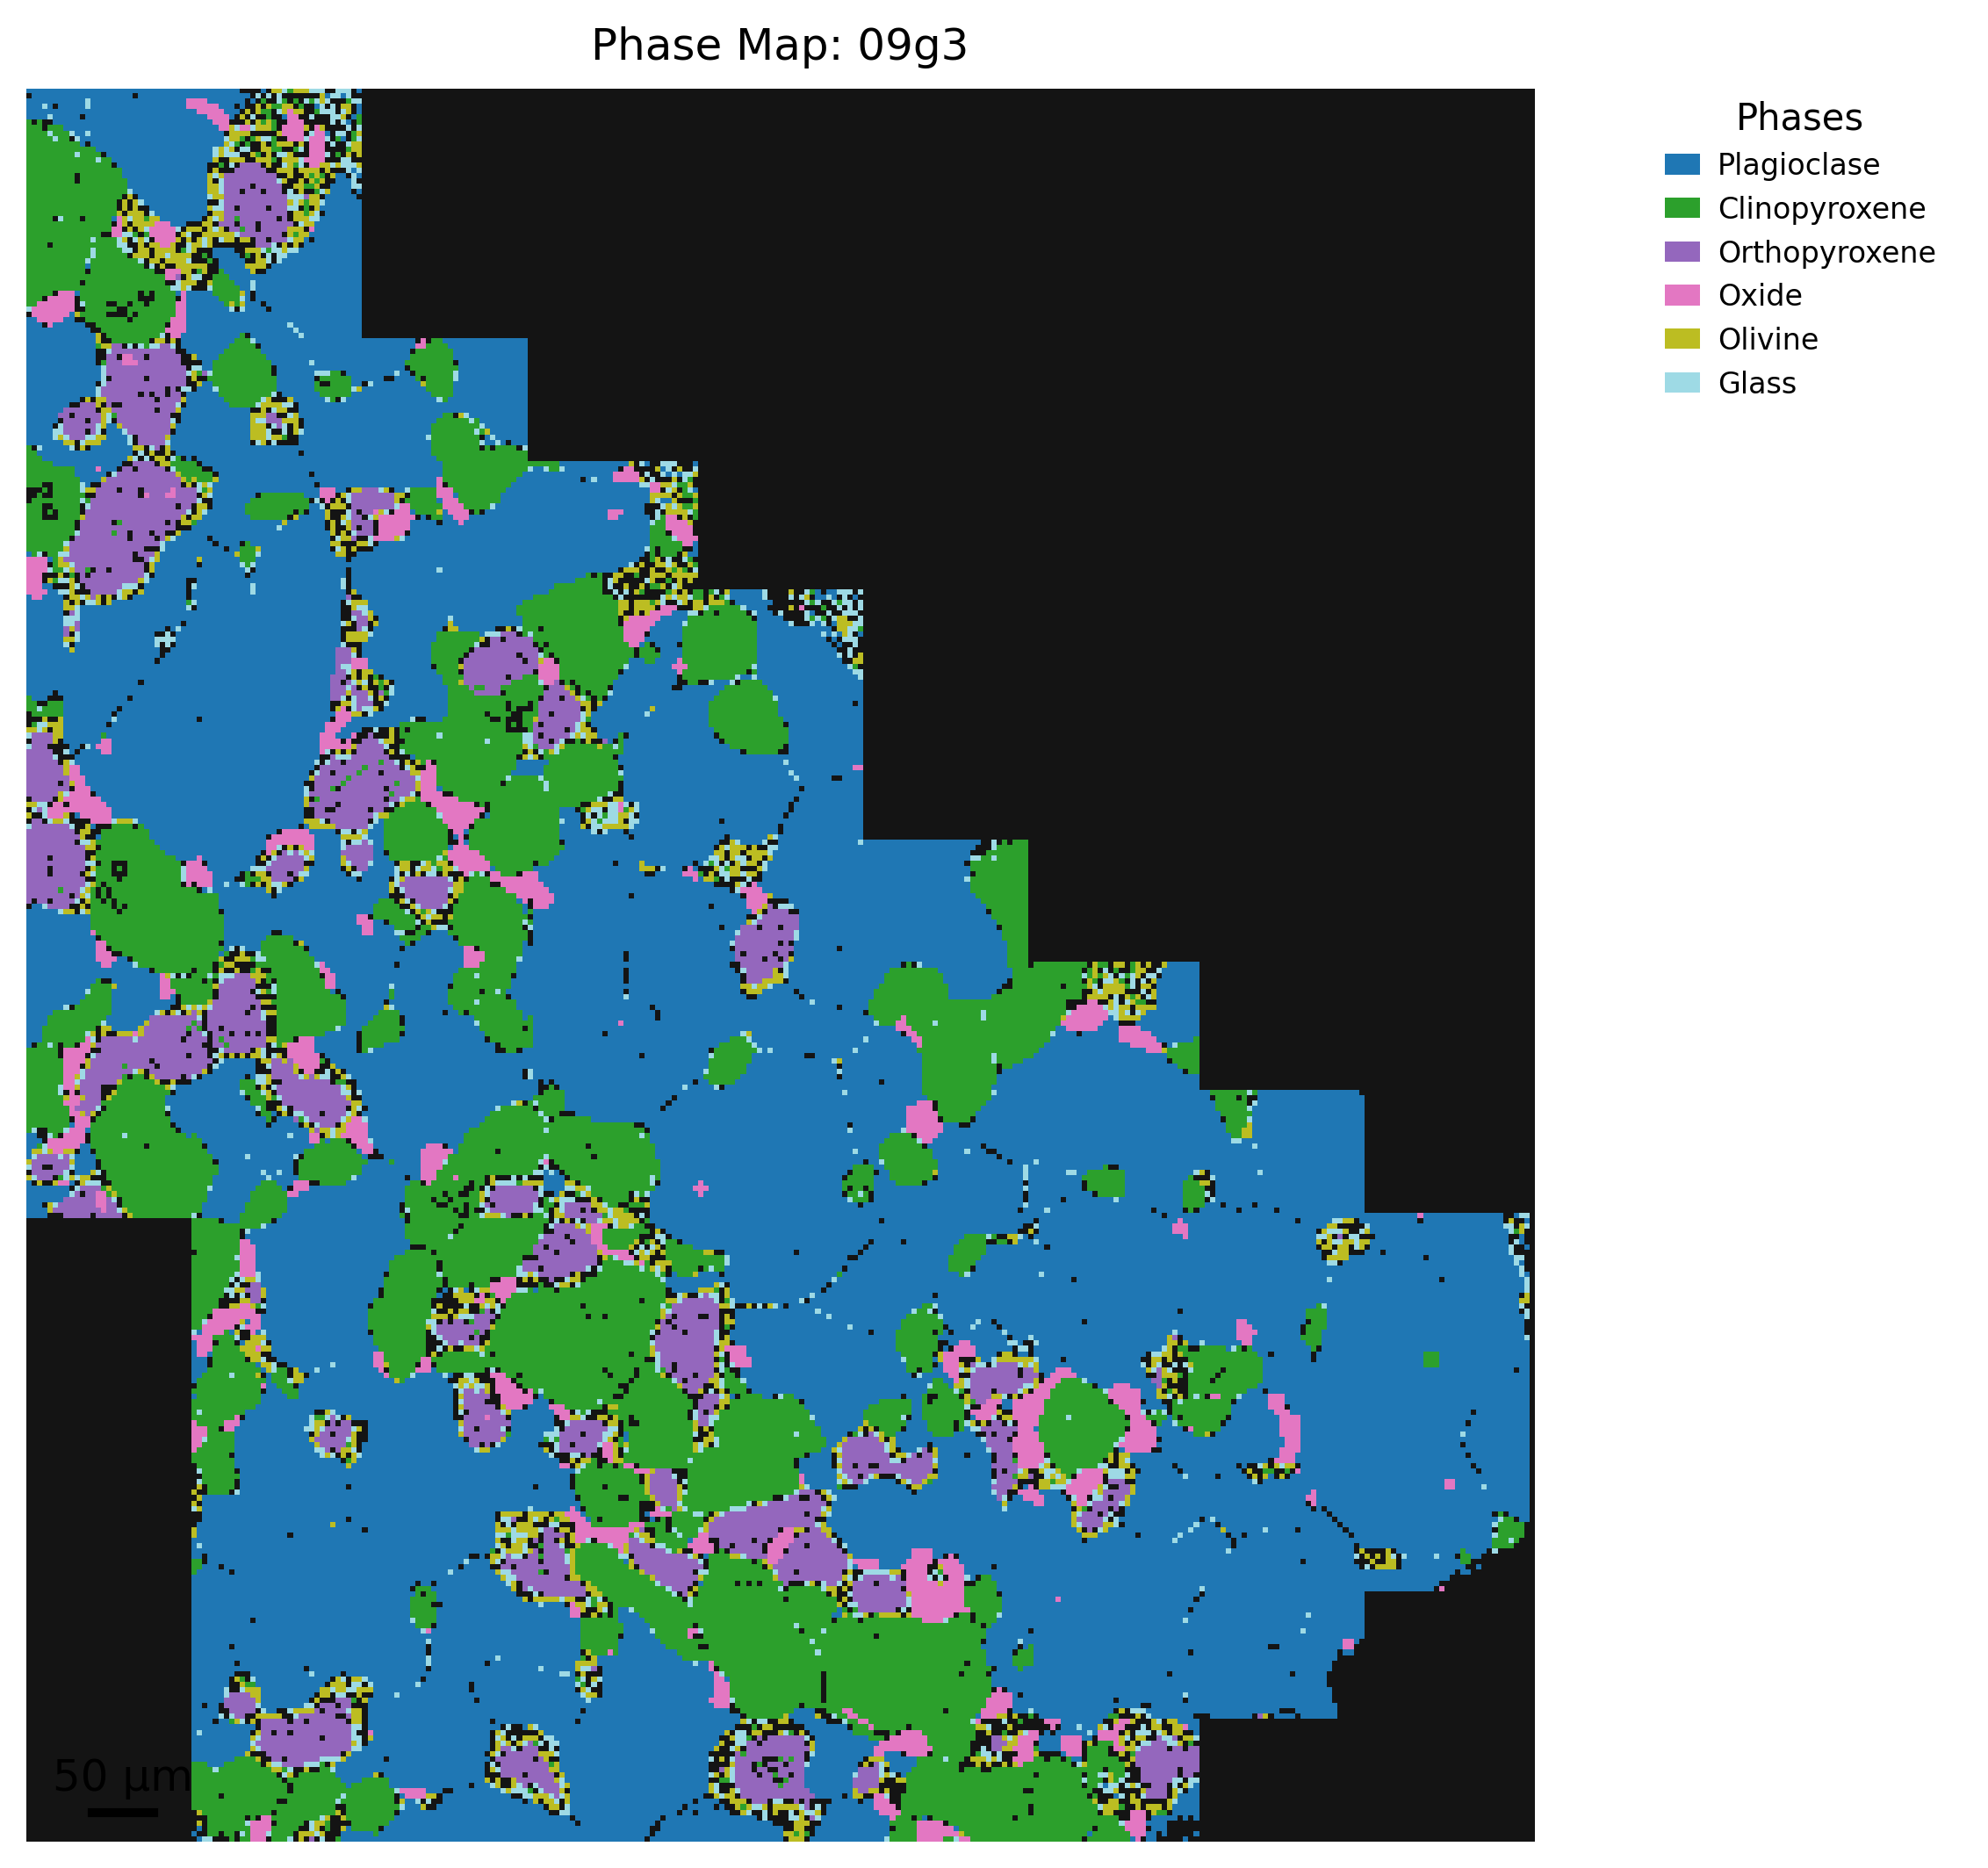

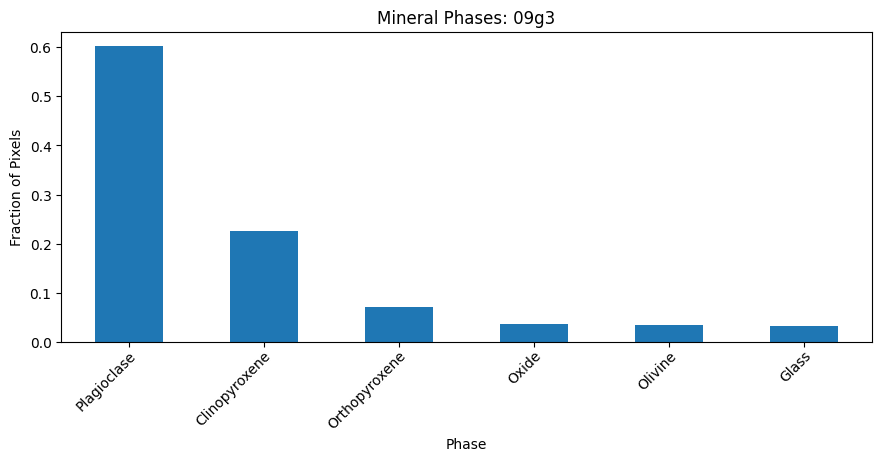

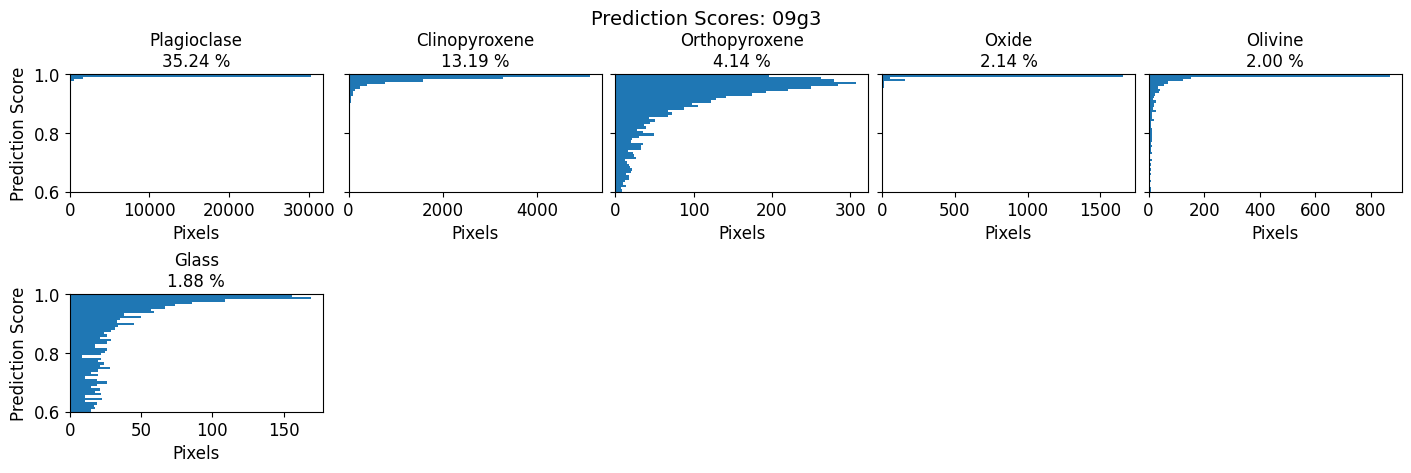

In [2]:
%matplotlib inline

result = mm.run_map(
    "Maps/09g3",
    renormalize=True,
    units="element_wt%",
    pixel_size_um=4.0,
    scalebar_um=50,
    total_threshold=50,
    min_frac=0.01,
)

## 2. Interactive pixel composition picker

`mm.interactive_pixels` displays the phase map and records the full oxide composition of each pixel you click. Each click:
- Places a marker on the map
- Prints the oxide values below the figure
- Appends a row to the dataframe in `controller["picks"]`

**Keybindings:** `r`/`u` undo last pick &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

After quitting, access your picks as a DataFrame:
```python
controller["picks"]
```

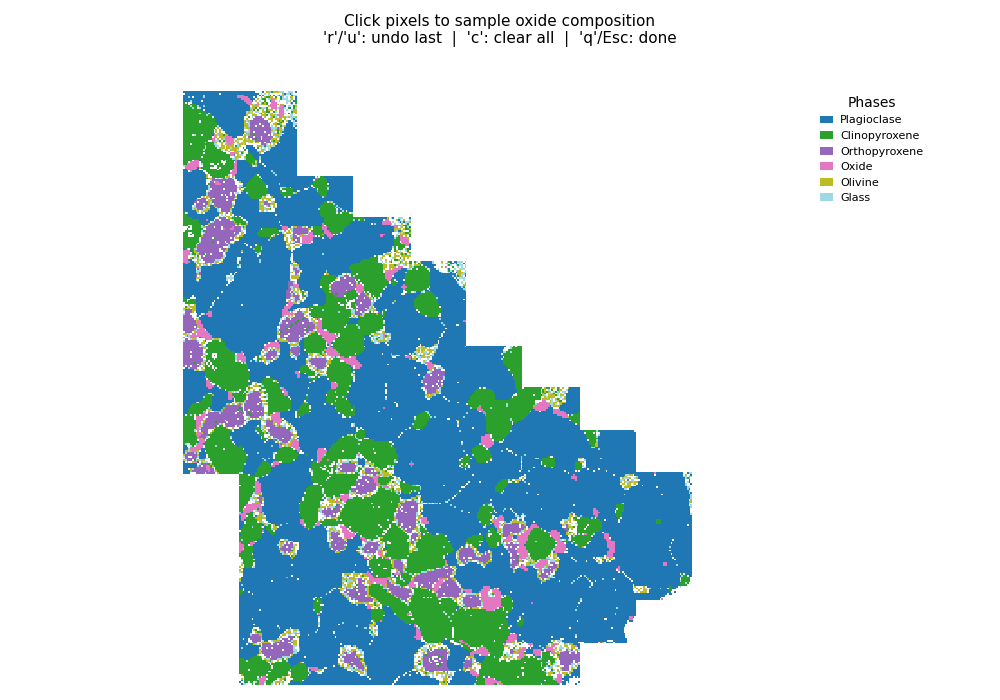

Output()

In [ ]:
%matplotlib widget

controller = mm.interactive_pixels(result,
                                   region=3, # side length of square averaging box (1 = single pixel; use odd integers, e.g. 3, 5)
                                   phase=None, # specify phase to display (e.g. "Plagioclase" or "plagioclase", case-insensitive; warns if not found in the map); if None, will display all pixels regardless of phase assignment
                                   )

In [4]:
%matplotlib inline

controller["picks"]

,x,y,phase,n_pixels,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,Cr2O3,Total,Total_raw
0,24,74,Orthopyroxene,9,51.382158,0.231275,5.935667,14.527422,0.092448,26.585354,0.838933,0.338983,-0.013140,0.080898,100.0,99.452320
1,14,85,Orthopyroxene,9,51.755858,0.266427,6.422178,13.811186,0.208105,26.407858,0.979675,0.164893,-0.041242,0.025062,100.0,99.796230
2,41,107,Plagioclase,9,51.243466,0.164586,31.054675,0.062434,-0.078979,-0.104385,13.301734,4.251682,0.276118,-0.171331,100.0,98.990366
3,38,128,Plagioclase,9,52.196867,-0.024729,30.320998,0.405566,-0.004646,0.046737,12.551467,4.307204,0.332112,-0.131575,100.0,98.874299
4,95,232,Clinopyroxene,9,49.447336,0.722313,8.024595,6.979877,0.101082,13.946927,19.894387,0.797412,0.256247,-0.170175,100.0,97.394634
5,103,240,Clinopyroxene,9,49.604274,0.561800,8.036716,6.500822,0.003462,13.893682,20.402058,0.840622,0.130585,0.025979,100.0,99.288592
6,168,283,Oxide,9,-0.048897,0.267502,59.991736,22.327466,-0.148192,15.930729,0.118597,0.117541,0.018457,1.425061,100.0,97.400370
7,173,283,Oxide,9,-0.249181,0.119954,60.926417,21.555273,-0.020259,16.497383,0.043414,-0.083181,-0.017739,1.227919,100.0,98.294721


### 2a. Filter to a specific phase

Pass `phase` to restrict the display and clicks to one or more mineral phases. Pixels outside the selected phase are shown as white background.

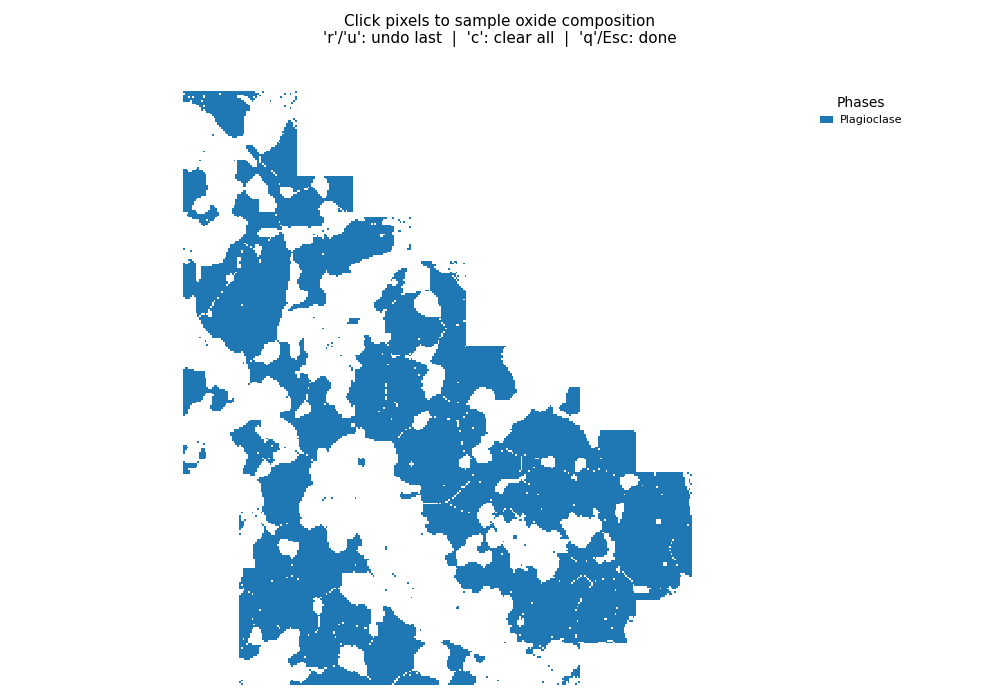

Output()

In [ ]:
%matplotlib widget

controller_plag = mm.interactive_pixels(result,
                                        region=3, # side length of square averaging box (1 = single pixel; use odd integers, e.g. 3, 5)
                                        phase="Plagioclase" # plot only pixels classified as plagioclase (optional; if None, will display all pixels regardless of phase assignment
                                        )

### 2b. Display an oxide heatmap as background

Pass `oxide_key` to show an oxide or component concentration map instead of the phase map. Combine with `phase` to restrict to a single mineral.

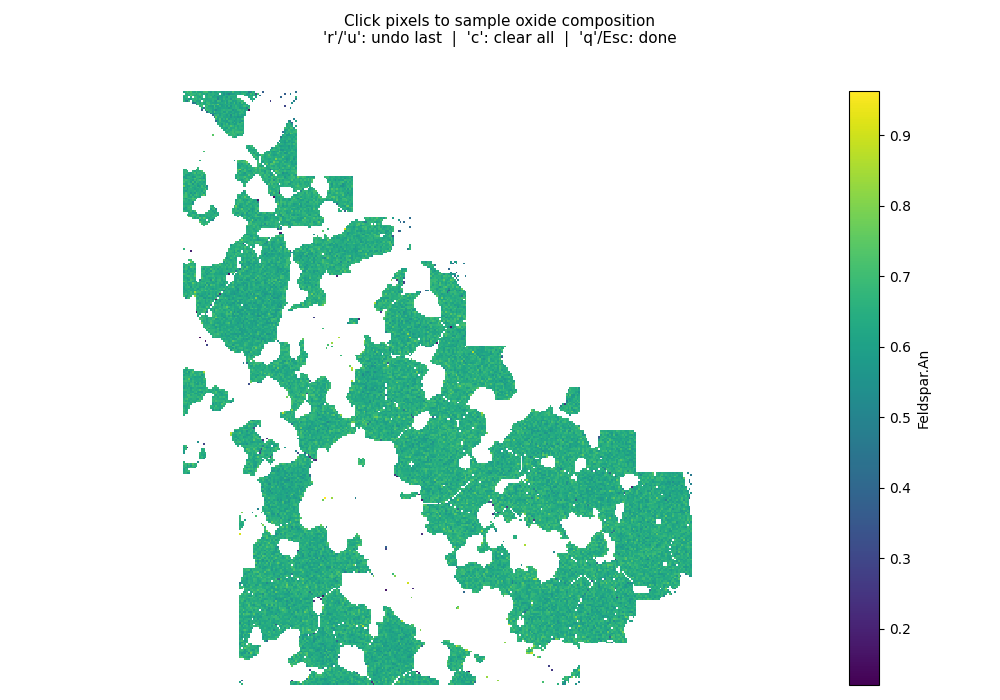

Output()

In [6]:
%matplotlib widget

controller_sio2 = mm.interactive_pixels(result,
                                        region=3, # side length of square averaging box (1 = single pixel; use odd integers, e.g. 3, 5)
                                        oxide_key="Feldspar.An", # plot An content of each pixel instead of phase assignment
                                        phase="Plagioclase" # plot only pixels classified as plagioclase (optional; if None, will display all pixels regardless of phase assignment
                                        )

## 3. Plot pick locations

`mm.plot_locations` overlays picked pixel locations on a map. Pass `map_key` to use an oxide map as the background.

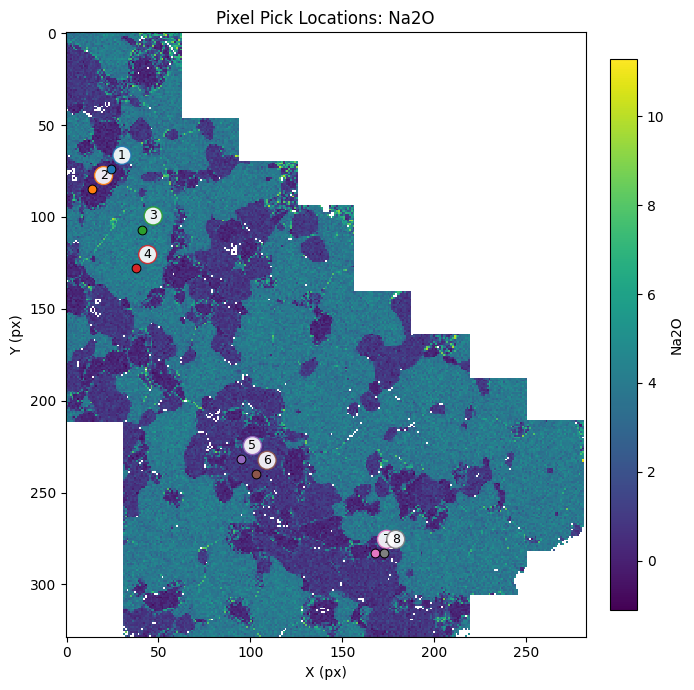

In [7]:
%matplotlib inline

fig, ax = mm.plot_locations(result,
                            controller["picks"], # plot only the pixels that have been picked
                            map_key="Na2O", # color the points by their Na2O content
                            )

## 4. Interactive line profiles

`mm.interactive_line_profile` lets you draw transects across a map by clicking a start and end point. Each completed transect is extracted and plotted immediately.

**Keybindings:** `r` reset current clicks &nbsp;|&nbsp; `u` undo last transect &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

Access results after quitting:
```python
lp["profiles_df"]     # all profile data concatenated
lp["coordinates_df"]  # transect start/end coordinates
```

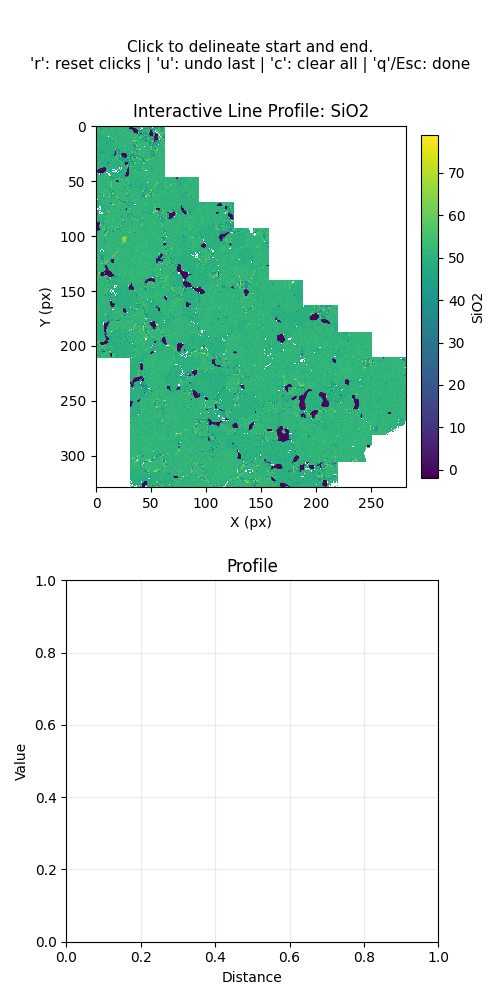

In [8]:
%matplotlib widget

lp = mm.interactive_line_profile(
    result,
    key="SiO2", # key of the oxide map to plot the line profile for
    method="none", # do not apply any smoothing to the line profile. use mean or median (across the pixel width) for a smoothed profile 
    width_px=5, # width of the line profile in pixels
    pixel_size_um=4.0, # pixel size in micrometers
)

### 4a. Filter transects to a single phase

Pass `phase` to mask the background map to pixels of a specific mineral before drawing transects.

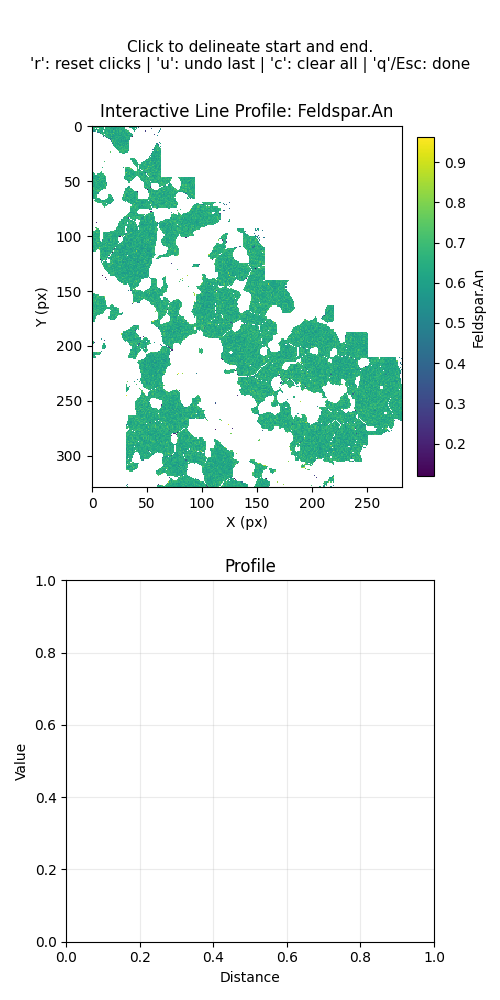

In [9]:
%matplotlib widget

lp_opx = mm.interactive_line_profile(
    result,
    key="Feldspar.An", # plot the Mg# of pixels classified as plagioclase
    phase="Plagioclase",
    method="none",
    width_px=5,
    pixel_size_um=4.0,
)

Return the line profile dataframe. 

In [10]:
%matplotlib inline

lp["profiles_df"]

,profile_id,distance_px,distance_um,SiO2,SiO2_smoothed,x,y,perp_distance_px,source,width_px,length_px,length_um,color,x0,y0,x1,y1
0,1,0.029312,0.117246,49.490084,49.490084,46.0,80.0,0.452090,auto,5.0,72.893565,291.574258,#1f77b4,46,80,30,151
1,1,0.254171,1.016684,48.257454,48.257454,45.0,80.0,1.426481,auto,5.0,72.893565,291.574258,#1f77b4,46,80,30,151
2,1,0.479031,1.916122,50.015794,50.015794,44.0,80.0,2.400872,auto,5.0,72.893565,291.574258,#1f77b4,46,80,30,151
3,1,0.553984,2.215935,40.963464,40.963464,48.0,81.0,-1.721552,auto,5.0,72.893565,291.574258,#1f77b4,46,80,30,151
4,1,0.778843,3.115373,53.601392,53.601392,47.0,81.0,-0.747161,auto,5.0,72.893565,291.574258,#1f77b4,46,80,30,151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,3,36.333159,145.332637,51.627654,51.627654,172.0,233.0,1.929236,auto,5.0,36.435405,145.741620,#2ca02c,173,197,174,233
751,3,36.358151,145.432606,60.081533,60.081533,173.0,233.0,0.929548,auto,5.0,36.435405,145.741620,#2ca02c,173,197,174,233
752,3,36.383144,145.532574,56.881043,56.881043,174.0,233.0,-0.070139,auto,5.0,36.435405,145.741620,#2ca02c,173,197,174,233
753,3,36.408136,145.632543,49.347756,49.347756,175.0,233.0,-1.069827,auto,5.0,36.435405,145.741620,#2ca02c,173,197,174,233


## 5. Plot transect locations

Pass the `coordinates_df` from a line profile controller to `mm.plot_locations` to visualize transect positions.

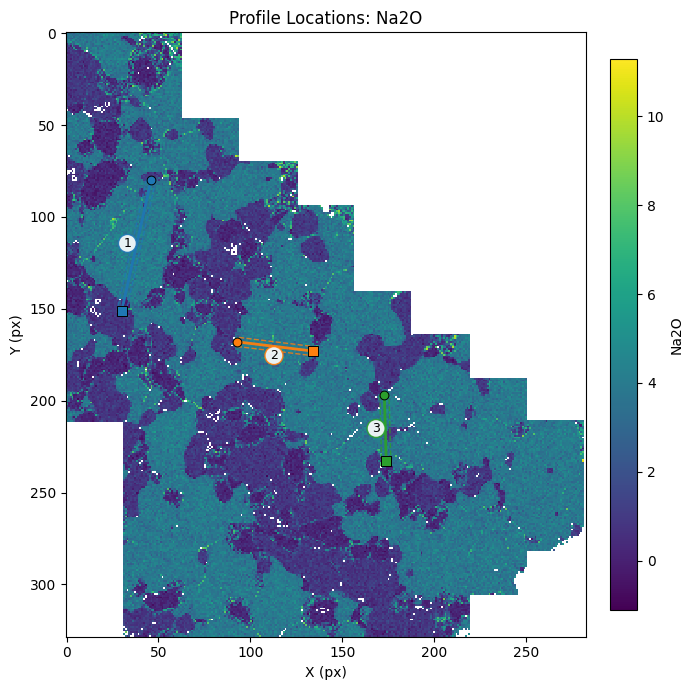

In [11]:
%matplotlib inline

fig, ax = mm.plot_locations(result, 
                            lp["coordinates_df"],
                            map_key="Na2O"
                            )

## 6. Batch extract profiles from saved transects

`mm.batch_extract_line_profiles` extracts profiles for multiple oxides at once from a saved transect table. Pass `lp["coordinates_df"]` from an interactive session, or any DataFrame with `x0`, `y0`, `x1`, `y1` columns.

Each oxide becomes its own column, making it easy to compare compositions along the same transect.

In [12]:
%matplotlib inline

profiles_df = mm.batch_extract_line_profiles(
    result,
    transects=lp["coordinates_df"],
    keys=["SiO2", "Al2O3", "FeOt", "MgO", "CaO", "Feldspar.An"],
    method="none",
    pixel_size_um=4.0,
)

profiles_df

,profile_id,x,y,distance_px,perp_distance_px,distance_um,SiO2,SiO2_smoothed,Al2O3,Al2O3_smoothed,...,CaO,CaO_smoothed,Feldspar.An,Feldspar.An_smoothed,x0,y0,x1,y1,width_px,source
0,1,46.0,80.0,0.000000,0.000000e+00,0.000000,49.490084,49.490084,7.699435,7.699435,...,21.724662,21.724662,NaN,NaN,46.0,80.0,30.0,151.0,5.0,auto
1,1,45.0,80.0,0.219839,9.755361e-01,0.879357,48.257454,48.257454,8.595989,8.595989,...,19.916674,19.916674,NaN,NaN,46.0,80.0,30.0,151.0,5.0,auto
2,1,44.0,80.0,0.439678,1.951072e+00,1.758713,50.015794,50.015794,8.705449,8.705449,...,20.377495,20.377495,NaN,NaN,46.0,80.0,30.0,151.0,5.0,auto
3,1,48.0,81.0,0.535858,-2.170911e+00,2.143432,40.963464,40.963464,8.341098,8.341098,...,2.822591,2.822591,NaN,NaN,46.0,80.0,30.0,151.0,5.0,auto
4,1,47.0,81.0,0.755697,-1.195375e+00,3.022788,53.601392,53.601392,28.690880,28.690880,...,10.621687,10.621687,0.547575,0.547575,46.0,80.0,30.0,151.0,5.0,auto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,3,175.0,232.0,35.042039,-1.027381e+00,140.168155,50.870222,50.870222,32.378985,32.378985,...,13.190178,13.190178,0.675179,0.675179,173.0,197.0,174.0,233.0,5.0,auto
747,3,176.0,232.0,35.069806,-2.026996e+00,140.279224,52.350337,52.350337,30.086376,30.086376,...,13.510627,13.510627,0.654615,0.654615,173.0,197.0,174.0,233.0,5.0,auto
748,3,172.0,233.0,35.958352,1.999229e+00,143.833408,51.627654,51.627654,30.454367,30.454367,...,10.819728,10.819728,0.499965,0.499965,173.0,197.0,174.0,233.0,5.0,auto
749,3,173.0,233.0,35.986119,9.996144e-01,143.944477,60.081533,60.081533,22.631185,22.631185,...,6.053288,6.053288,NaN,NaN,173.0,197.0,174.0,233.0,5.0,auto


In [13]:
# Long format — one row per oxide per distance bin, useful for plotting
profiles_df, profiles_long_df = mm.batch_extract_line_profiles(
    result,
    transects=lp["coordinates_df"],
    keys=["SiO2", "MgO", "CaO"],
    method="mean",
    pixel_size_um=4.0,
    return_long=True,
)

profiles_long_df

,bin,distance_px,value,n_pixels,distance_um,value_smoothed,profile_id,key,source,x0,y0,x1,y1,width_px
0,0,0.099427,49.490084,1,0.397708,49.490084,1,SiO2,auto,46.0,80.0,30.0,151.0,5.0
1,1,0.298281,48.257454,1,1.193123,48.257454,1,SiO2,auto,46.0,80.0,30.0,151.0,5.0
2,2,0.497135,45.489629,2,1.988538,45.489629,1,SiO2,auto,46.0,80.0,30.0,151.0,5.0
3,3,0.695988,53.601392,1,2.783953,53.601392,1,SiO2,auto,46.0,80.0,30.0,151.0,5.0
4,4,0.894842,50.561281,1,3.579368,50.561281,1,SiO2,auto,46.0,80.0,30.0,151.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260,180,35.137873,13.350402,2,140.551491,13.350402,3,CaO,auto,173.0,197.0,174.0,233.0,5.0
2261,181,35.332542,NaN,0,141.330170,NaN,3,CaO,auto,173.0,197.0,174.0,233.0,5.0
2262,182,35.527212,NaN,0,142.108848,NaN,3,CaO,auto,173.0,197.0,174.0,233.0,5.0
2263,183,35.721882,NaN,0,142.887527,NaN,3,CaO,auto,173.0,197.0,174.0,233.0,5.0


## 7. Composite component map

`mm.plot_component_composite` overlays continuous solid-solution compositions (e.g. plagioclase An%, olivine Fo%, pyroxene XMg) on top of a categorical phase map. This gives a single figure showing both phase identity and mineral chemistry.

The component maps are computed automatically by `run_map` and stored in `result["component_maps"]`.

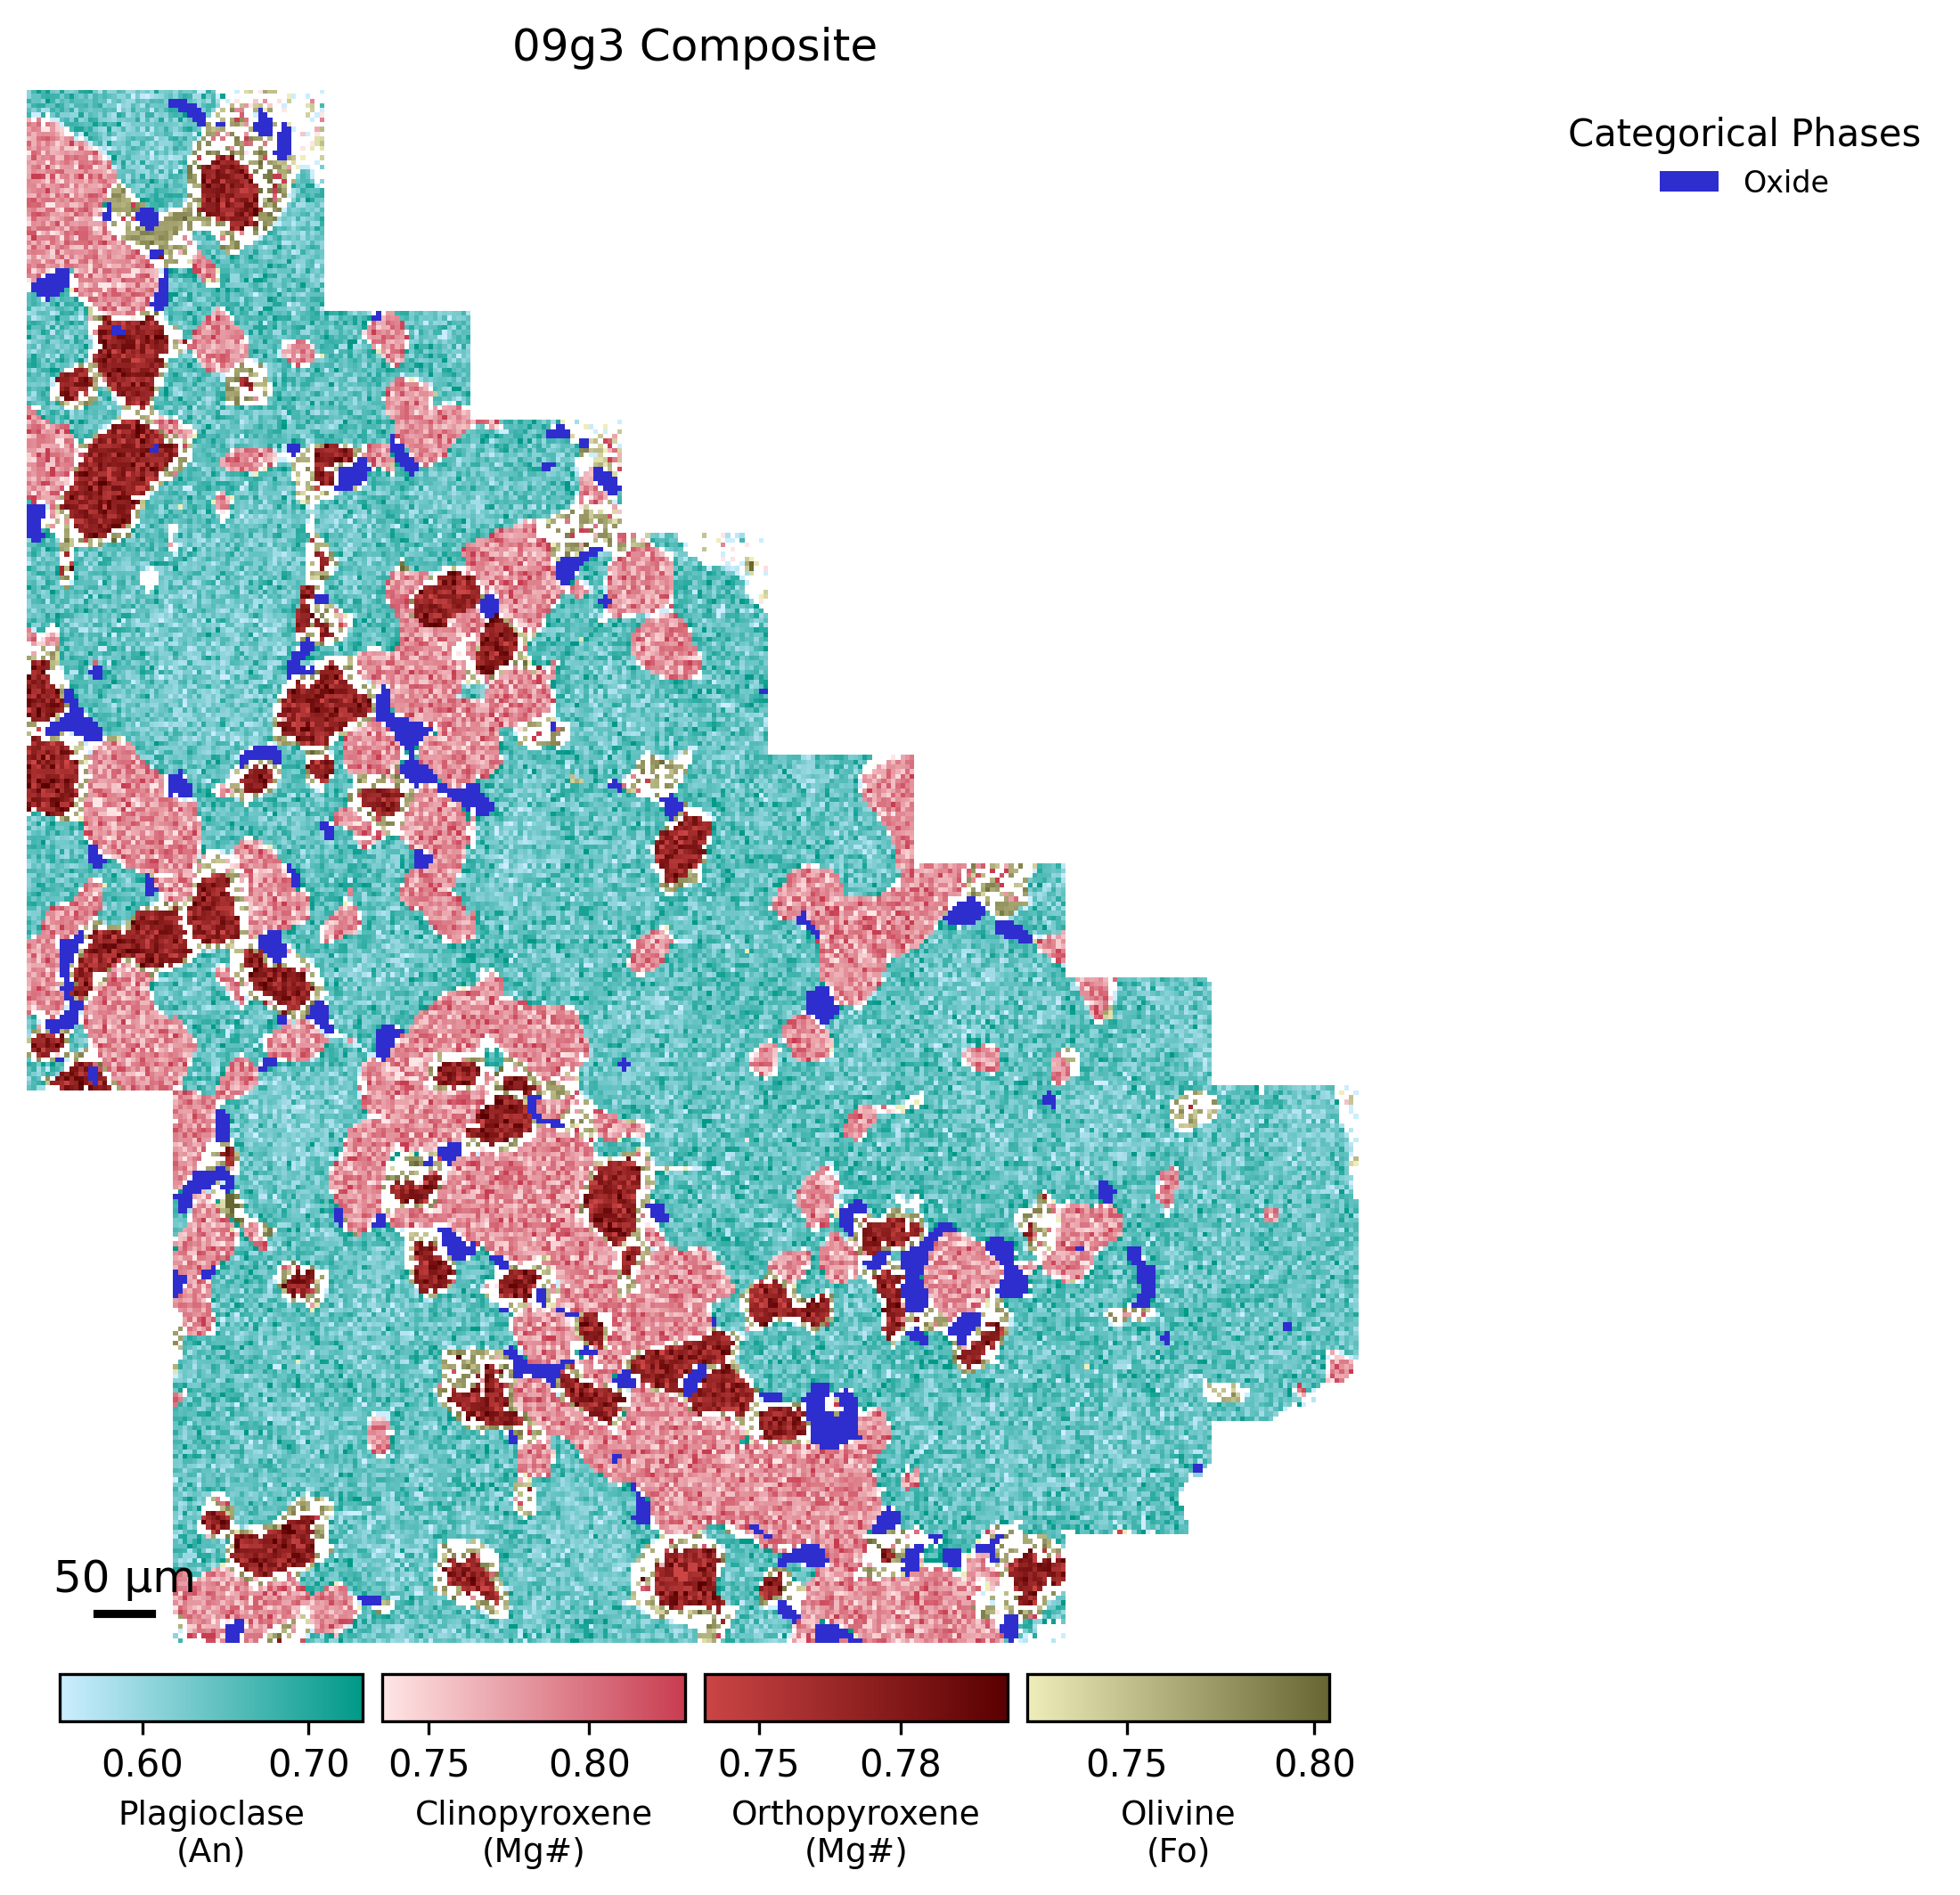

In [14]:
%matplotlib inline
# You can restrict which phases appear and adjust the color limits. `limits_mode="std"` clips the colorbar to the 2 sigma range of each component, which is useful when a few extreme pixels would otherwise compress the color scale.

fig, mineral_map, comp_maps = mm.plot_component_composite(
    result,
    title="09g3 Composite",
    pixel_size_um=4.0,
    scalebar_um=50,
    limits_mode="std", # 2 sigma range for color limits
)